# 분류 프로젝트 - student stress level

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 데이터 준비

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/fly ai/dataset/student-lifestyle-and-stress-dataset.csv')

Mounted at /content/drive


In [ ]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,24167.0,6.458948,1.504228,2.008586,5.438360,6.542566,7.531571,9.997527
Study_Hours,24223.0,4.696477,2.240148,-1.433434,3.078230,4.538138,6.135670,22.444460
Social_Media_Hours,24188.0,3.555614,1.901528,0.000040,2.152249,3.500709,4.864312,9.962134
Attendance,24195.0,81.270961,12.052045,-5.000000,73.738894,81.942959,90.106859,120.000000
Exam_Pressure,24230.0,5.369748,2.394003,1.000000,4.000000,5.000000,7.000000,10.000000
Family_Support,24209.0,5.798298,2.232371,1.000000,4.000000,6.000000,7.000000,10.000000
Month,24186.0,6.500992,3.455308,1.000000,3.000000,6.000000,10.000000,12.000000
Stress_Level,25500.0,0.299882,0.458215,0.000000,0.000000,0.000000,1.000000,1.000000


In [ ]:
df.loc[df["Study_Hours"] < 0, :].shape, df.loc[(df["Attendance"] < 0) | (df["Attendance"] > 100), :].shape

((21, 9), (112, 9))

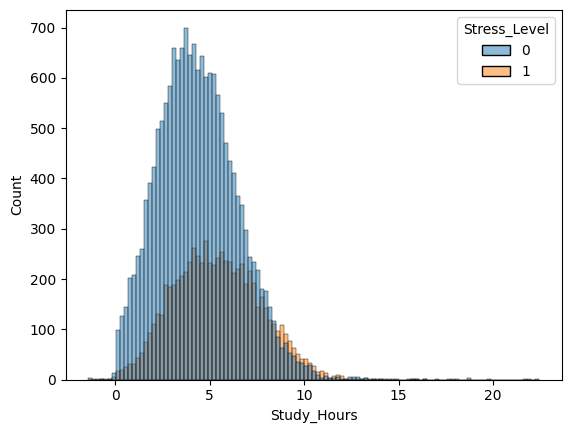

In [ ]:
sns.histplot(x="Study_Hours", hue="Stress_Level", data=df)
plt.show()

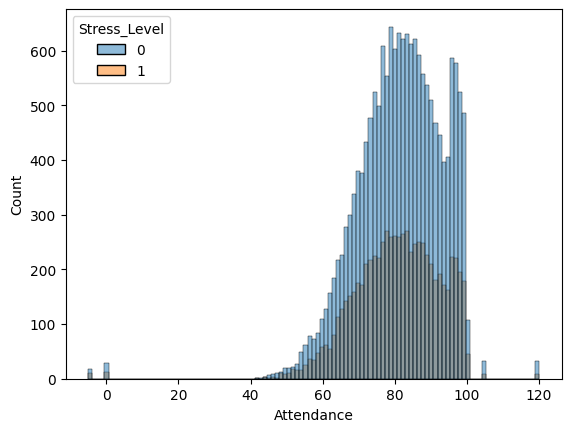

In [ ]:
sns.histplot(x="Attendance", hue="Stress_Level", data=df)
plt.show()

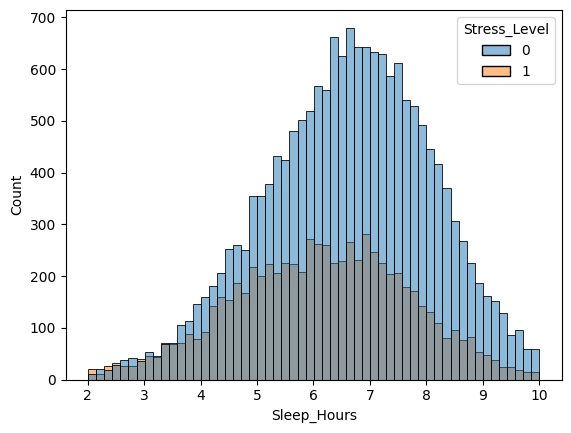

In [ ]:
sns.histplot(x="Sleep_Hours", hue="Stress_Level", data=df)
plt.show()

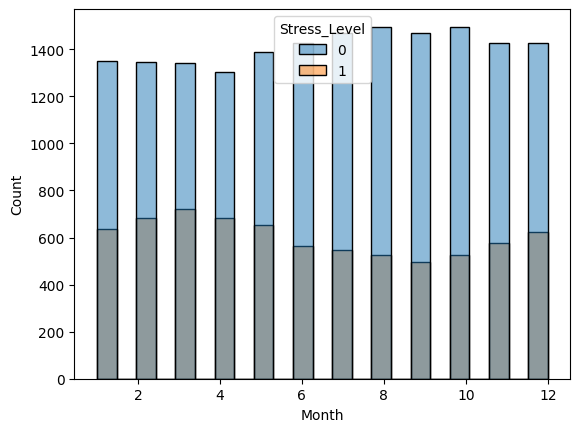

In [ ]:
sns.histplot(x="Month", hue="Stress_Level", data=df)
plt.show()

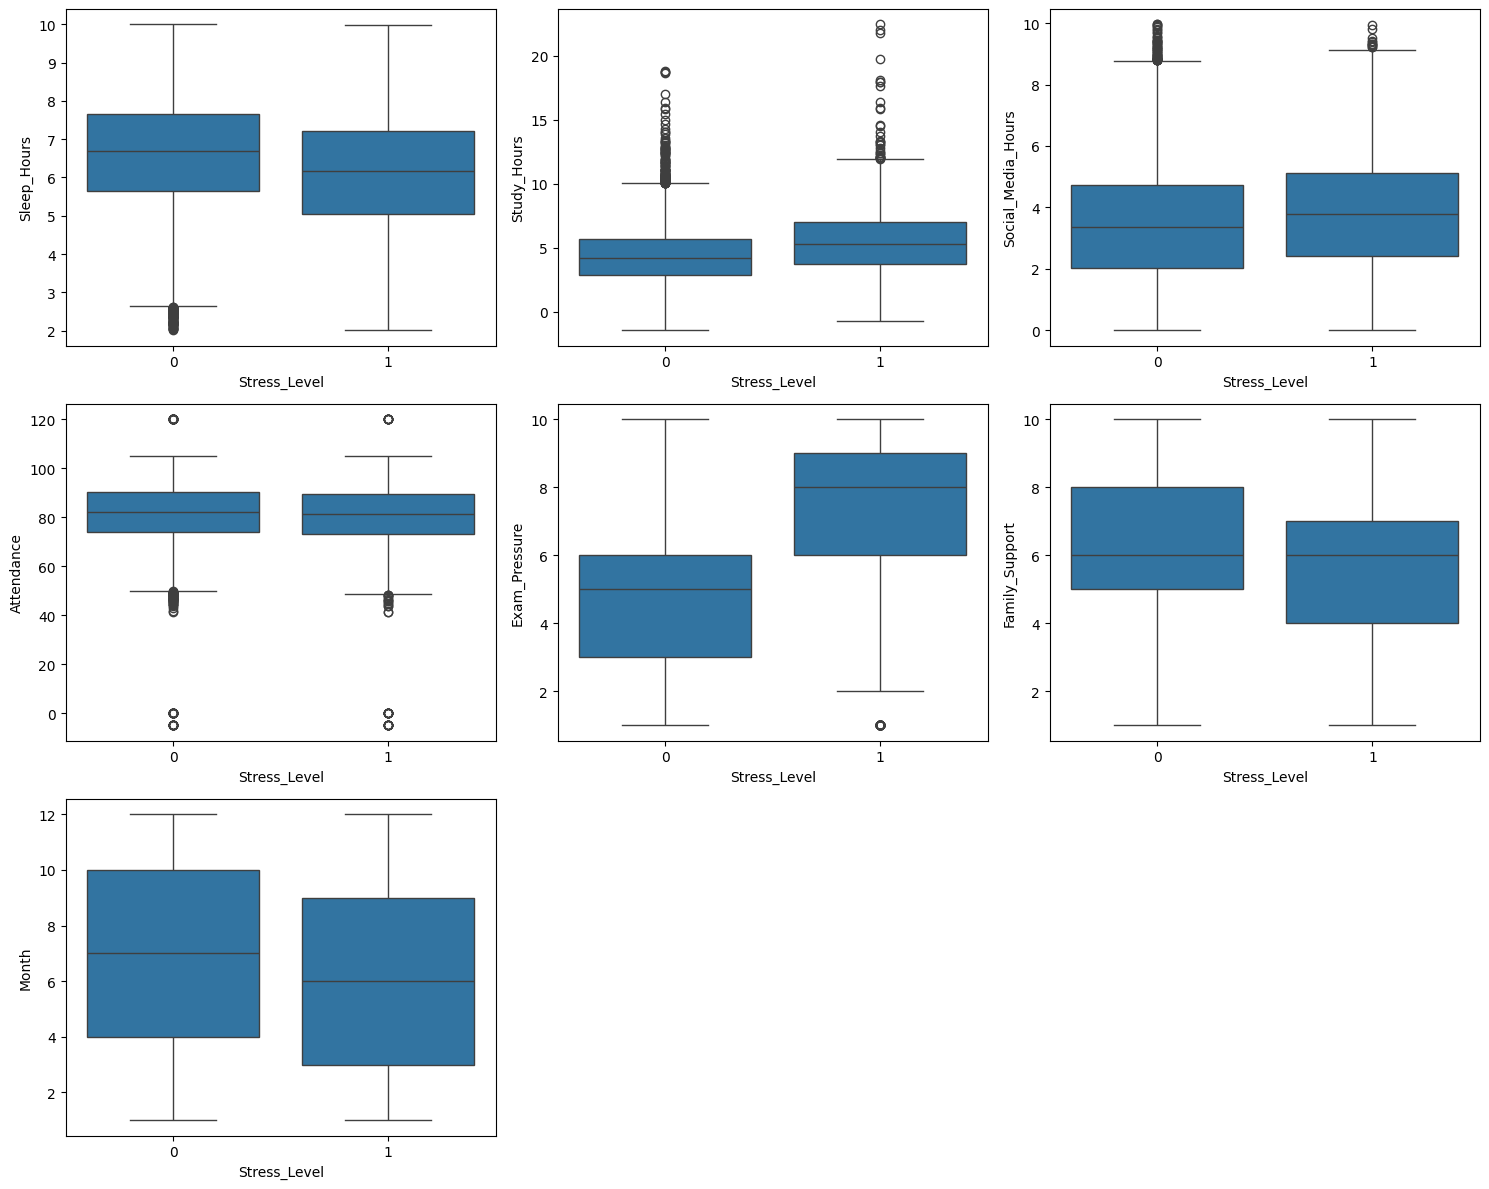

In [ ]:
numerical_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Stress_Level', y=col, data=df, ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 결측치 처리

In [ ]:
df.columns

Index(['Student_Type', 'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
       'Attendance', 'Exam_Pressure', 'Family_Support', 'Month',
       'Stress_Level'],
      dtype='object')

In [ ]:
df = df.loc[(df['Sleep_Hours'] >= 0) | (df['Sleep_Hours'].isna()), :]
df = df.loc[((df['Attendance'] >= 0) & (df['Attendance'] <= 100)) | (df['Attendance'].isna()), :]

In [ ]:
df.shape

(25388, 9)

## 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=SEED, shuffle=True)
train.shape, test.shape

((20310, 9), (5078, 9))

In [ ]:
X_train = train.drop(columns=["Stress_Level"])
y_train = train["Stress_Level"]
X_test = test.drop(columns=["Stress_Level"])
y_test = test["Stress_Level"]

## 결측치 처리

In [ ]:
mean_values = {}
mode_values = {}
num_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance']

for col in num_cols:
  u = X_train[col].mean()
  X_train[col] = X_train[col].fillna(u)
  mean_values[col] = u

cat_col = ['Student_Type', 'Month', 'Exam_Pressure', 'Family_Support']
for col in cat_col:
  m = X_train[col].mode()[0]
  X_train[col] = X_train[col].fillna(m)
  mode_values[col] = m

In [ ]:
X_train.isna().sum()
mean_values, mode_values

({'Sleep_Hours': np.float64(6.456130085724191),
  'Study_Hours': np.float64(4.695339002608892),
  'Social_Media_Hours': np.float64(3.558950333634032),
  'Attendance': np.float64(81.28135706549392)},
 {'Student_Type': 'college',
  'Month': np.float64(5.0),
  'Exam_Pressure': np.float64(5.0),
  'Family_Support': np.float64(6.0)})

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Columns to apply One-Hot Encoding
columns_to_encode = ['Student_Type', 'Month']

# Initialize OneHotEncoder
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform on X_train
encoded_features_train = one_hot_encoder.fit_transform(X_train[columns_to_encode])

# Create a DataFrame from the encoded features with appropriate column names
encoded_df_train = pd.DataFrame(encoded_features_train,
                                columns=one_hot_encoder.get_feature_names_out(columns_to_encode),
                                index=X_train.index)

# Drop original categorical columns and concatenate with encoded features
X_train = pd.concat([X_train.drop(columns=columns_to_encode), encoded_df_train], axis=1)

print("One-Hot Encoding applied to 'Student_Type' and 'Month' in X_train.")
print("Shape of X_train after encoding:", X_train.shape)
print("One-Hot Encoder stored for later use:", one_hot_encoder)


One-Hot Encoding applied to 'Student_Type' and 'Month' in X_train.
Shape of X_train after encoding: (20310, 21)
One-Hot Encoder stored for later use: OneHotEncoder(handle_unknown='ignore', sparse_output=False)


In [ ]:
X_train

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Student_Type_college,Student_Type_school,Student_Type_working_student,Month_1.0,...,Month_3.0,Month_4.0,Month_5.0,Month_6.0,Month_7.0,Month_8.0,Month_9.0,Month_10.0,Month_11.0,Month_12.0
24343,8.061076,2.660372,3.977174,93.973357,2.0,7.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12051,8.871063,1.121346,4.552338,95.829021,3.0,5.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12033,6.942413,6.422681,2.107978,85.791884,5.0,7.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14441,8.004814,5.642917,2.582393,98.702494,2.0,4.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
17744,8.872258,0.690998,5.234778,80.271366,8.0,3.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21670,5.993701,3.542965,0.034163,72.414528,6.0,8.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5416,7.977808,4.695339,1.896982,55.301933,6.0,6.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
866,6.268092,3.029528,0.095667,71.033805,7.0,6.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
15870,6.827641,4.407283,3.950493,83.211119,2.0,7.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_features_to_scale = [
    'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
    'Attendance', 'Exam_Pressure', 'Family_Support'
]

scaler = StandardScaler()

X_train[numerical_features_to_scale] = scaler.fit_transform(X_train[numerical_features_to_scale])

print("Standard scaling applied to numerical features in X_train.")
print("Fitted StandardScaler stored for later use:", scaler)
print("X_train head after scaling:\n", X_train.head())

Standard scaling applied to numerical features in X_train.
Fitted StandardScaler stored for later use: StandardScaler()
X_train head after scaling:
        Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
24343     1.095044    -0.934186            0.226464    1.131546   
12051     1.647693    -1.640703            0.537910    1.296986   
12033     0.331787     0.792966           -0.785687    0.402133   
14441     1.056657     0.435002           -0.528796    1.553169   
17744     1.648508    -1.838261            0.907444   -0.090045   

       Exam_Pressure  Family_Support  Student_Type_college  \
24343      -1.437113        0.545968                   1.0   
12051      -1.007963       -0.369538                   0.0   
12033      -0.149664        0.545968                   1.0   
14441      -1.437113       -0.827291                   1.0   
17744       1.137786       -1.285043                   1.0   

       Student_Type_school  Student_Type_working_student  Month_1.0  ...  \

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# --- SVM GridSearchCV ---
print("Starting GridSearchCV for SVM...")
clf_svm = SVC(random_state=SEED)

param_grid_svm = {
    'C' : [0.01, 0.1, 1.0, 10],
    'gamma' : ["scale", "auto"],
    'kernel' : ["rbf", "poly"]
}

grid_search_svm = GridSearchCV(
    estimator=clf_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search_svm.fit(X_train, y_train)

print("\nSVM Best Parameters:", grid_search_svm.best_params_)
print("SVM Best Score:", grid_search_svm.best_score_)


# --- RandomForest GridSearchCV ---
print("\nStarting GridSearchCV for RandomForest...")
clf_rf = RandomForestClassifier(random_state=SEED)

param_grid_rf = {
    'n_estimators': [100, 200], # Number of trees in the forest
    'max_depth': [10, 20, None], # Maximum depth of the tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

grid_search_rf = GridSearchCV(
    estimator=clf_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1 # Added verbose for better progress indication
)

grid_search_rf.fit(X_train, y_train)

print("\nRandomForest Best Parameters:", grid_search_rf.best_params_)
print("RandomForest Best Score:", grid_search_rf.best_score_)

# Store best estimators for future use
best_svm_model = grid_search_svm.best_estimator_
best_rf_model = grid_search_rf.best_estimator_

print("\nBest SVM Model stored as 'best_svm_model':", best_svm_model)
print("Best RandomForest Model stored as 'best_rf_model':", best_rf_model)


Starting GridSearchCV for SVM...

SVM Best Parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
SVM Best Score: 0.8162973904480552

Starting GridSearchCV for RandomForest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

RandomForest Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
RandomForest Best Score: 0.8155588380108322

Best SVM Model stored as 'best_svm_model': SVC(C=0.1, gamma='auto', random_state=42)
Best RandomForest Model stored as 'best_rf_model': RandomForestClassifier(min_samples_leaf=2, n_estimators=200, random_state=42)


In [ ]:
# 1. Impute missing values in X_test using mean_values and mode_values from X_train
print("Imputing missing values in X_test...")
# Numerical columns for mean imputation
for col, mean_val in mean_values.items():
    if col in X_test.columns:
        X_test[col].fillna(mean_val, inplace=True)

# Categorical columns for mode imputation
for col, mode_val in mode_values.items():
    if col in X_test.columns:
        X_test[col].fillna(mode_val, inplace=True)

print("Missing values in X_test after imputation:\n", X_test.isnull().sum().sum())

# 2. One-Hot Encode categorical features in X_test using the fitted one_hot_encoder
print("\nApplying One-Hot Encoding to X_test...")
# Ensure columns_to_encode is defined from previous step, if not, define here
# columns_to_encode = ['Student_Type', 'Month'] # Uncomment if not globally available

# Transform X_test using the fitted OneHotEncoder
encoded_features_test = one_hot_encoder.transform(X_test[columns_to_encode])

# Create a DataFrame from the encoded features with appropriate column names
encoded_df_test = pd.DataFrame(encoded_features_test,
                               columns=one_hot_encoder.get_feature_names_out(columns_to_encode),
                               index=X_test.index)

# Drop original categorical columns and concatenate with encoded features
X_test = pd.concat([X_test.drop(columns=columns_to_encode), encoded_df_test], axis=1)

print("One-Hot Encoding applied to 'Student_Type' and 'Month' in X_test.")
print("Shape of X_test after encoding:", X_test.shape)

# 3. Scale numerical features in X_test using the fitted scaler
print("\nApplying Standard Scaling to X_test...")
# Ensure numerical_features_to_scale is defined from previous step
# numerical_features_to_scale = [
#     'Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
#     'Attendance', 'Exam_Pressure', 'Family_Support'
# ] # Uncomment if not globally available

X_test[numerical_features_to_scale] = scaler.transform(X_test[numerical_features_to_scale])

print("Standard scaling applied to numerical features in X_test.")
print("X_test head after all preprocessing:\n", X_test.head())


Imputing missing values in X_test...
Missing values in X_test after imputation:
 0

Applying One-Hot Encoding to X_test...
One-Hot Encoding applied to 'Student_Type' and 'Month' in X_test.
Shape of X_test after encoding: (5078, 21)

Applying Standard Scaling to X_test...
Standard scaling applied to numerical features in X_test.
X_test head after all preprocessing:
        Sleep_Hours  Study_Hours  Social_Media_Hours    Attendance  \
8199      0.189335    -1.609065            0.322942 -5.616059e-01   
11497     0.598781    -1.040441           -1.550925  1.369596e+00   
14038    -0.981384    -0.420014           -0.303370  1.266958e-15   
1345     -0.381375     0.478209            0.877704  1.654241e+00   
17789    -0.417978    -0.992311           -0.015151 -7.187556e-01   

       Exam_Pressure  Family_Support  Student_Type_college  \
8199       -1.007963        0.545968                   1.0   
11497       1.996085       -1.285043                   0.0   
14038      -0.149664        1.0

/tmp/ipykernel_718/458544955.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test[col].fillna(mean_val, inplace=True)
/tmp/ipykernel_718/458544955.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred)
    print(f"4. F1 Score: {f1:.4f}")



    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

In [ ]:
y_pred_rf = best_rf_model.predict(X_test)
y_pred_svm = best_svm_model.predict(X_test)
#y_pred_knn = best_knn_model.predict(X_test)

1. Accuracy: 0.8135
2. Recall: 0.5917
3. Precision: 0.7304
4. F1 Score: 0.6537


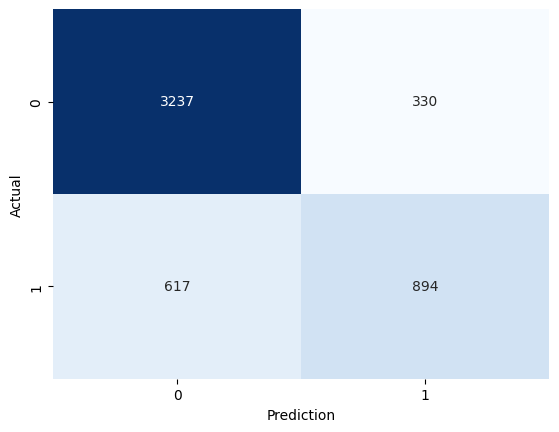

1. Accuracy: 0.8153
2. Recall: 0.5764
3. Precision: 0.7451
4. F1 Score: 0.6500


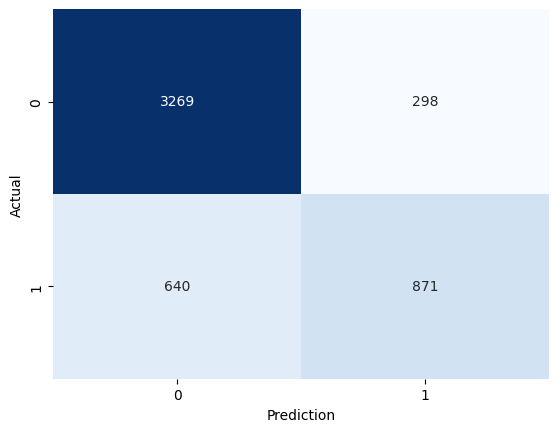

In [ ]:
print_metrics(y_test, y_pred_rf)
print_metrics(y_test, y_pred_svm)
#print_metrics(y_test, y_pred_knn)

